# Module 2 Chapter 4: 联邦学习（Federated Learning）与 FedAvg

本 Notebook 对应 CAISP 模块二《技术基础篇》中关于联邦学习的内容（参考页 1417-1486）。

联邦学习（FL）允许多个客户端在本地训练模型，仅将模型更新（而非原始数据）发送到中央服务器聚合。
我们将从零实现 **FedAvg** 算法，并在 CIFAR-10 上对比：

- 集中式训练（Centralized）：所有数据聚合在一起训练。
- 联邦学习-IID（Federated-IID）：数据均匀随机划分到 5 个客户端。
- 联邦学习-non-IID（Federated-non-IID）：每个客户端仅拥有 2 个类别，模拟真实数据异构场景。

> 注意：不依赖 PySyft、Flower 等外部库，仅使用 PyTorch 与 NumPy。


In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备：{device}')


使用设备：cuda


## 1. 联邦学习基本概念

**FedAvg 流程（McMahan et al.）**：
1. 服务器初始化全局模型。
2. 每轮通信：服务器将全局模型发送给选定的客户端。
3. 客户端在本地数据上执行若干轮（E epochs）SGD，得到本地模型。
4. 客户端将本地模型权重（不是原始数据）发送回服务器。
5. 服务器按各客户端数据量加权平均，更新全局模型。

**隐私优势**：原始数据始终保留在客户端本地，服务器只收到聚合后的模型参数。

**注意**：FL 本身并不提供严格的隐私保证。模型更新仍可能泄露数据信息（如梯度泄露攻击），因此常与差分隐私（DP）或安全多方计算（MPC）结合使用。


## 2. CIFAR-10 数据加载

使用本地 `data/cifar-10-batches-py/` 目录中的二进制数据。


In [2]:
CIFAR_DIR = 'data/cifar-10-batches-py'

def load_cifar10_batch(filename):
    """
    加载 CIFAR-10 单个 batch。
    """
    with open(os.path.join(CIFAR_DIR, filename), 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    data = batch[b'data'] / 255.0
    labels = np.array(batch[b'labels'])
    return data.astype(np.float32), labels

def load_cifar10():
    """
    加载完整 CIFAR-10 训练集与测试集。
    """
    train_data, train_labels = [], []
    for i in range(1, 6):
        d, l = load_cifar10_batch(f'data_batch_{i}')
        train_data.append(d)
        train_labels.append(l)
    train_data = np.concatenate(train_data, axis=0)
    train_labels = np.concatenate(train_labels, axis=0)

    test_data, test_labels = load_cifar10_batch('test_batch')

    train_data = train_data.reshape(-1, 3, 32, 32)
    test_data = test_data.reshape(-1, 3, 32, 32)

    return train_data, train_labels, test_data, test_labels

X_train, y_train, X_test, y_test = load_cifar10()
print(f'训练集：{X_train.shape}')
print(f'测试集：{X_test.shape}')


训练集：(50000, 3, 32, 32)
测试集：(10000, 3, 32, 32)


## 3. 模型与评估函数

使用与 FGSM/PGD 以及 DP Notebook 中一致的 SimpleCNN。


In [3]:
class SimpleCNN(nn.Module):
    """
    简单的 CNN，适用于 CIFAR-10 10 分类。
    """
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def evaluate(model, data, labels, batch_size=256):
    """
    评估模型在给定数据集上的准确率。
    """
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            x = torch.from_numpy(data[i:i+batch_size]).to(device)
            y = torch.from_numpy(labels[i:i+batch_size]).to(device)
            outputs = model(x)
            _, pred = outputs.max(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total


## 4. 客户端数据划分：IID vs non-IID

- **IID**：将训练集随机打乱后均匀分配给 5 个客户端。
- **non-IID**：按类别排序，每个客户端分得 2 个类别（shard partition），模拟真实数据分布不均。


In [4]:
NUM_CLIENTS = 5

def partition_iid(data, labels, num_clients):
    """
    IID 划分：随机打乱后均分为 num_clients 份。
    """
    n = len(data)
    indices = np.random.permutation(n)
    shard_size = n // num_clients
    client_data, client_labels = [], []
    for k in range(num_clients):
        start = k * shard_size
        end = (k + 1) * shard_size if k < num_clients - 1 else n
        client_data.append(data[indices[start:end]])
        client_labels.append(labels[indices[start:end]])
    return client_data, client_labels

def partition_non_iid(data, labels, num_clients):
    """
    non-IID 划分：按类别排序，每个客户端分得 2 个类别。
    """
    sorted_indices = np.argsort(labels)
    sorted_data = data[sorted_indices]
    sorted_labels = labels[sorted_indices]

    client_data, client_labels = [], []
    for k in range(num_clients):
        class_a = 2 * k
        class_b = 2 * k + 1
        mask = (sorted_labels == class_a) | (sorted_labels == class_b)
        client_data.append(sorted_data[mask])
        client_labels.append(sorted_labels[mask])
    return client_data, client_labels

client_data_iid, client_labels_iid = partition_iid(X_train, y_train, NUM_CLIENTS)
client_data_noniid, client_labels_noniid = partition_non_iid(X_train, y_train, NUM_CLIENTS)

print('IID 客户端数据量：', [len(d) for d in client_data_iid])
print('non-IID 客户端数据量：', [len(d) for d in client_data_noniid])

print('\nnon-IID 客户端类别分布：')
for k in range(NUM_CLIENTS):
    unique, counts = np.unique(client_labels_noniid[k], return_counts=True)
    print(f'  Client {k}: {dict(zip(unique, counts))}')


IID 客户端数据量： [10000, 10000, 10000, 10000, 10000]
non-IID 客户端数据量： [10000, 10000, 10000, 10000, 10000]

non-IID 客户端类别分布：
  Client 0: {np.int64(0): np.int64(5000), np.int64(1): np.int64(5000)}
  Client 1: {np.int64(2): np.int64(5000), np.int64(3): np.int64(5000)}
  Client 2: {np.int64(4): np.int64(5000), np.int64(5): np.int64(5000)}
  Client 3: {np.int64(6): np.int64(5000), np.int64(7): np.int64(5000)}
  Client 4: {np.int64(8): np.int64(5000), np.int64(9): np.int64(5000)}


## 5. 本地训练与 FedAvg 聚合

实现本地训练函数与 FedAvg 服务器聚合函数。
聚合时按各客户端数据量加权，保证数据量大的客户端贡献更大。


In [5]:
def local_train(model, data, labels, epochs, lr, batch_size):
    """
    客户端本地训练。
    """
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    n = len(data)
    for _ in range(epochs):
        perm = np.random.permutation(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            x = torch.from_numpy(data[idx]).to(device)
            y = torch.from_numpy(labels[idx]).to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

def federated_train(server_model, client_data, client_labels, rounds, local_epochs, lr, batch_size):
    """
    FedAvg 联邦训练主循环。
    """
    global_weights = server_model.state_dict()
    num_clients = len(client_data)
    client_sizes = [len(d) for d in client_data]
    total_size = sum(client_sizes)

    history = []
    for r in range(rounds):
        local_weights = []
        for k in range(num_clients):
            local_model = SimpleCNN().to(device)
            local_model.load_state_dict(global_weights)
            local_train(local_model, client_data[k], client_labels[k],
                        local_epochs, lr, batch_size)
            local_weights.append(local_model.state_dict())

        # 加权平均聚合（FedAvg）
        aggregated_weights = {}
        for key in local_weights[0].keys():
            weighted_sum = sum(local_weights[k][key] * (client_sizes[k] / total_size)
                               for k in range(num_clients))
            aggregated_weights[key] = weighted_sum
        global_weights = aggregated_weights
        server_model.load_state_dict(global_weights)

        acc = evaluate(server_model, X_test, y_test)
        history.append(acc)
        print(f'Round {r+1}/{rounds}, Test Acc: {acc:.4f}')
    return history


## 6. 集中式训练基线

作为对比，在所有训练数据上直接执行 SGD。
为保证公平，总训练轮数 = 联邦轮数 × 本地 epoch 数。


In [6]:
def train_centralized(model, data, labels, epochs, lr, batch_size):
    """
    集中式训练。
    """
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    n = len(data)
    history = []
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            x = torch.from_numpy(data[idx]).to(device)
            y = torch.from_numpy(labels[idx]).to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
        acc = evaluate(model, X_test, y_test)
        history.append(acc)
        print(f'Epoch {epoch+1}/{epochs}, Test Acc: {acc:.4f}')
    return history

# 超参数
ROUNDS = 5
LOCAL_EPOCHS = 2
LR = 0.01
BATCH_SIZE = 256
CENTRAL_EPOCHS = ROUNDS * LOCAL_EPOCHS


## 7. 运行三种训练模式并对比

分别训练集中式、联邦-IID、联邦-non-IID 三种模型。


In [7]:
print('==> 1. 集中式训练')
model_central = SimpleCNN().to(device)
hist_central = train_centralized(model_central, X_train, y_train, CENTRAL_EPOCHS, LR, BATCH_SIZE)

print('\n==> 2. 联邦学习（IID 划分）')
model_fed_iid = SimpleCNN().to(device)
hist_fed_iid = federated_train(model_fed_iid, client_data_iid, client_labels_iid,
                              ROUNDS, LOCAL_EPOCHS, LR, BATCH_SIZE)

print('\n==> 3. 联邦学习（non-IID 划分）')
model_fed_noniid = SimpleCNN().to(device)
hist_fed_noniid = federated_train(model_fed_noniid, client_data_noniid, client_labels_noniid,
                                 ROUNDS, LOCAL_EPOCHS, LR, BATCH_SIZE)


==> 1. 集中式训练
Epoch 1/10, Test Acc: 0.1409
Epoch 2/10, Test Acc: 0.1314
Epoch 3/10, Test Acc: 0.1637
Epoch 4/10, Test Acc: 0.2392
Epoch 5/10, Test Acc: 0.2634
Epoch 6/10, Test Acc: 0.2997
Epoch 7/10, Test Acc: 0.2993
Epoch 8/10, Test Acc: 0.3371
Epoch 9/10, Test Acc: 0.3381
Epoch 10/10, Test Acc: 0.3438

==> 2. 联邦学习（IID 划分）
Round 1/5, Test Acc: 0.1107
Round 2/5, Test Acc: 0.1195
Round 3/5, Test Acc: 0.1094
Round 4/5, Test Acc: 0.1194
Round 5/5, Test Acc: 0.1546

==> 3. 联邦学习（non-IID 划分）
Round 1/5, Test Acc: 0.0963
Round 2/5, Test Acc: 0.1225
Round 3/5, Test Acc: 0.1440
Round 4/5, Test Acc: 0.1269
Round 5/5, Test Acc: 0.1595


## 8. 结果可视化：准确率 vs 通信轮数

联邦学习通信轮数对应于集中式训练 epoch 数。


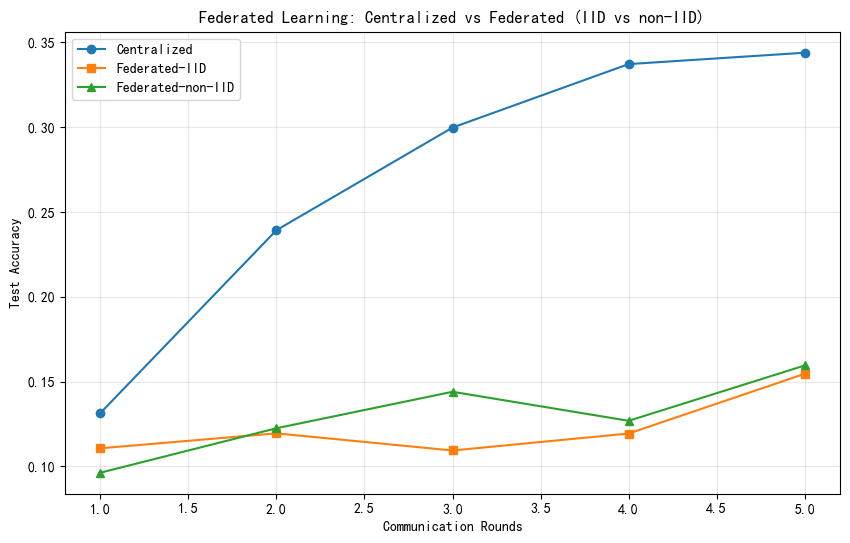

In [8]:
# 将集中式训练结果按联邦轮数抽样：每 LOCAL_EPOCHS 个 epoch 取一个点
central_for_plot = [hist_central[i] for i in range(LOCAL_EPOCHS - 1, CENTRAL_EPOCHS, LOCAL_EPOCHS)]
rounds = list(range(1, ROUNDS + 1))

plt.figure(figsize=(10, 6))
plt.plot(rounds, central_for_plot, marker='o', label='Centralized')
plt.plot(rounds, hist_fed_iid, marker='s', label='Federated-IID')
plt.plot(rounds, hist_fed_noniid, marker='^', label='Federated-non-IID')
plt.xlabel('Communication Rounds')
plt.ylabel('Test Accuracy')
plt.title('Federated Learning: Centralized vs Federated (IID vs non-IID)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 9. 联邦学习的隐私特性：客户端只上传模型权重

下面展示：客户端发送给服务器的内容是模型权重张量，而不是原始图像数据。
这避免了原始数据在通信链路中的直接暴露。


In [9]:
# 演示：一个客户端的模型权重 vs 原始数据大小
sample_model = SimpleCNN().to(device)
weight_size = 0
for name, param in sample_model.named_parameters():
    weight_size += param.numel() * param.element_size()
    print(f'参数 {name}: shape={tuple(param.shape)}, numel={param.numel()}')

# 单个客户端的数据大小（仅作对比）
client0_data_size = client_data_iid[0].nbytes
print(f'\n单个客户端模型权重总大小：{weight_size / 1024:.2f} KB')
print(f'单个客户端原始数据大小：{client0_data_size / 1024 / 1024:.2f} MB')
print(f'\n结论：客户端上传的是模型权重（{weight_size/1024:.2f} KB），而不是原始数据（{client0_data_size/1024/1024:.2f} MB）。')


参数 conv1.weight: shape=(16, 3, 3, 3), numel=432
参数 conv1.bias: shape=(16,), numel=16
参数 conv2.weight: shape=(32, 16, 3, 3), numel=4608
参数 conv2.bias: shape=(32,), numel=32
参数 fc1.weight: shape=(128, 2048), numel=262144
参数 fc1.bias: shape=(128,), numel=128
参数 fc2.weight: shape=(10, 128), numel=1280
参数 fc2.bias: shape=(10,), numel=10

单个客户端模型权重总大小：1049.41 KB
单个客户端原始数据大小：117.19 MB

结论：客户端上传的是模型权重（1049.41 KB），而不是原始数据（117.19 MB）。


#### 客户端数据分布：IID vs Non-IID

下面展示两种联邦学习数据分区下每个客户端拥有的类别分布。IID 分区中每个客户端近似拥有所有类别；Non-IID 分区中每个客户端仅拥有 2 个类别，导致客户端数据分布差异大，这是联邦学习收敛困难的主要原因。

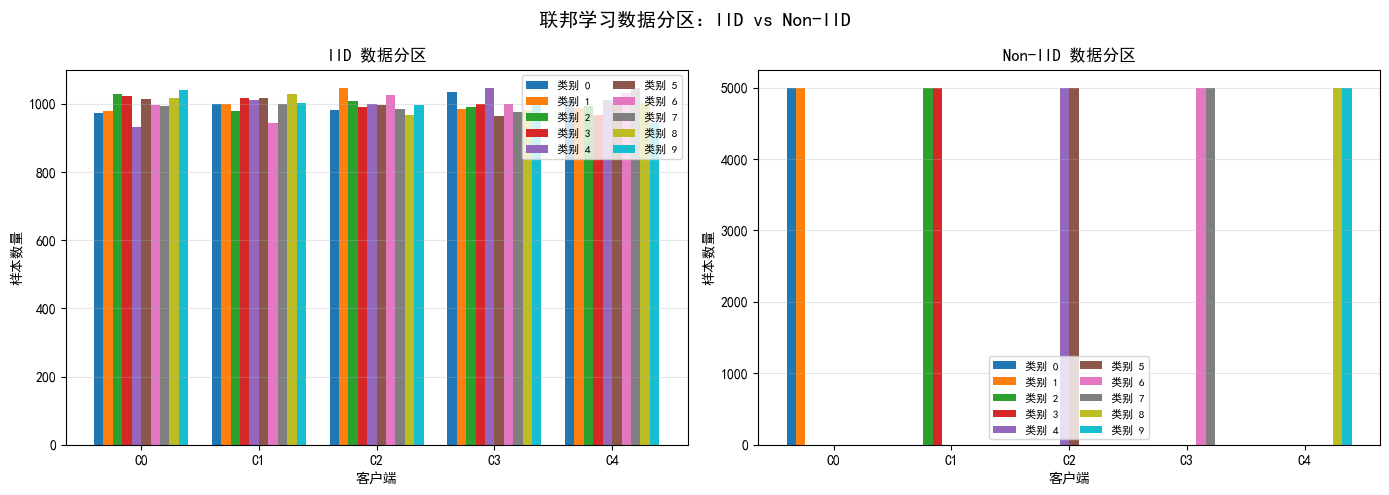

In [10]:
# 可视化 IID 与 Non-IID 数据分区下每个客户端的类别分布
classes = list(range(10))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IID 客户端类别分布
iid_counts = np.zeros((NUM_CLIENTS, 10))
for k in range(NUM_CLIENTS):
    unique, counts = np.unique(client_labels_iid[k], return_counts=True)
    iid_counts[k, unique] = counts

x = np.arange(NUM_CLIENTS)
width = 0.08
for c in range(10):
    axes[0].bar(x + c * width, iid_counts[:, c], width, label=f"类别 {c}")
axes[0].set_xlabel("客户端")
axes[0].set_ylabel("样本数量")
axes[0].set_title("IID 数据分区")
axes[0].set_xticks(x + width * 4.5)
axes[0].set_xticklabels([f"C{k}" for k in range(NUM_CLIENTS)])
axes[0].legend(ncol=2, fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Non-IID 客户端类别分布
noniid_counts = np.zeros((NUM_CLIENTS, 10))
for k in range(NUM_CLIENTS):
    unique, counts = np.unique(client_labels_noniid[k], return_counts=True)
    noniid_counts[k, unique] = counts

for c in range(10):
    axes[1].bar(x + c * width, noniid_counts[:, c], width, label=f"类别 {c}")
axes[1].set_xlabel("客户端")
axes[1].set_ylabel("样本数量")
axes[1].set_title("Non-IID 数据分区")
axes[1].set_xticks(x + width * 4.5)
axes[1].set_xticklabels([f"C{k}" for k in range(NUM_CLIENTS)])
axes[1].legend(ncol=2, fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("联邦学习数据分区：IID vs Non-IID", fontsize=14)
plt.tight_layout()
plt.show()


## 10. 联邦学习的局限性与安全建议

虽然联邦学习避免了原始数据外传，但仍面临多种安全与隐私威胁：

| 威胁 | 说明 | 应对措施 |
|---|---|---|
| 模型投毒（Model Poisoning） | 恶意客户端上传篡改后的本地模型，破坏全局模型 | 拜占庭容错聚合、梯度裁剪、异常检测 |
| 梯度泄露（Gradient Leakage） | 服务器或窃听者从模型更新中反推原始数据 | 差分隐私（DP）加密梯度、安全聚合（Secure Aggregation） |
| 推理攻击（Inference Attacks） | 从全局模型推断客户端属性或成员信息 | 限制模型发布、DP 训练、隐私审计 |
| 非独立同分布（non-IID） | 数据分布不均导致全局模型收敛慢或性能差 | 个性化联邦学习、本地微调、改进聚合算法 |

**结论**：联邦学习是“数据不动模型动”的分布式训练范式，能够降低数据集中化带来的泄露风险，但本身不等同于隐私保护。
要实现严格隐私保证，通常需要将 FL 与差分隐私（参考 Notebook 2）或安全多方计算（MPC）结合使用。
